# This script is to read in the .prof and measurement files for comparisons

In [ ]:
import pandas as pd
import glob
from pathlib import Path
import numpy as np

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.stats import sigma_clip

import matplotlib.pyplot as plt

import sys
import os

from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import FlatLambdaCDM

h = 0.7
cosmo = FlatLambdaCDM(H0=h * 100, Om0=0.3)

# funciton to load profile and measurement files. 
> Since Radii and Median flux measurements from the annuli method is now combined with isophote measurements as seperate columns in .prof files, loading measurement files are not necessary, unless some double checking and debugging is required.


In [ ]:
def load_profiles_and_measurements(
    outdir,
    cluster_id,
    filter_name,
    prefixes,
    mask_filter_name=None,
    pixelscale=0.3,
    load_measurement_file=False,
    forced_photometry=False,
    forced_profile_filter=None,
):
    profiles = []
    measurements = []

    mask_filter_name = mask_filter_name or filter_name

    for prefix in prefixes:
        # Construct label: include mask_filter_name only if different from filter_name
        label_parts = [cluster_id, filter_name]

        if mask_filter_name != filter_name:
            label_parts.append(mask_filter_name)

        if prefix:
            label_parts.append(prefix)

        if forced_photometry:
            if not forced_profile_filter:
                raise ValueError(
                    "forced_profile_filter must be defined while forced_photometry=True"
                )
            label_parts.append(f"fp_{forced_profile_filter}")

        label = "_".join(label_parts)

        # Construct profile filename similarly
        filename_parts = [cluster_id, filter_name]
        if mask_filter_name != filter_name:
            filename_parts.append(mask_filter_name)

        if prefix:
            filename_parts.append(prefix)

        if forced_photometry:
            if not forced_profile_filter:
                raise ValueError(
                    "forced_profile_filter must be defined while forced_photometry=True"
                )
            filename_parts.append(f"fp_{forced_profile_filter}")

        prof_filename = "_".join(filename_parts) + ".prof"

        prof_path = outdir / cluster_id / "autoprof_results" / prof_filename

        if prof_path.exists():
            try:
                prof_df = pd.read_csv(prof_path, skiprows=1)
                profiles.append((label, prof_df))
            except Exception as e:
                print(f"[ERROR] Failed to read profile file {prof_path}: {e}")
        else:
            print(f"[INFO] Profile file not found: {prof_path}")

        # Load measurement file (optional)
        if load_measurement_file:
            if forced_photometry:
                if not forced_profile_filter:
                    raise ValueError(
                        "forced_profile_filter must be defined while forced_photometry=True"
                    )
                label.append(f"_fp_{forced_profile_filter}")

            meas_filename = (
                f"Profile_measurements_{label}.csv"
                if prefix
                else "Profile_measurements.csv"
            )
            meas_path = outdir / cluster_id / meas_filename

            if meas_path.exists():
                try:
                    meas_df = pd.read_csv(meas_path)
                    measurements.append((label, meas_df))
                except Exception as e:
                    print(f"[ERROR] Failed to read measurement file {meas_path}: {e}")
            else:
                print(f"[INFO] Measurement file not found: {meas_path}")

    if load_measurement_file:
        return profiles, measurements
    else:
        return profiles

# function to plot Surface Brigthness profiles. 
> Multiple files can be loaded for comparisons.

In [ ]:
def plot_sb_profiles(
    profiles=None,
    measurements=None,
    pixelscale=0.3,
    rad_output_unit="pix",
    cosmology=None,
    redshift=None,
    specific_profile_prefix=None,
    plot_profiles=True,
    plot_measurements=True,
    xlog=True,
    ylog=True,
    ax=None,
    savefig=False,
    outdir=None,
    prefix_colors=None,
    legendloc="lower left",
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    if prefix_colors is None:
        prefix_colors = {}

    allowed_labels = set(specific_profile_prefix) if specific_profile_prefix else None

    # Unit conversion
    if rad_output_unit == "pix":
        scale_conversion = 1 / pixelscale
    elif rad_output_unit == "arcsec":
        scale_conversion = 1
    elif rad_output_unit == "kpc":
        if cosmology is None or redshift is None:
            raise ValueError(
                "Cosmology and redshift must be provided for kpc conversion."
            )
        scale_conversion = 1 / cosmology.arcsec_per_kpc_proper(redshift).value
    else:
        raise ValueError(f"Unsupported rad_output_unit: {rad_output_unit}")

    # Default styles
    styles = {
        "isophote": {"linestyle": "-", "marker": "o"},
        "annuli": {"linestyle": "--", "marker": "s"},
        "external": {"linestyle": ":", "marker": "^"},
    }

    # Internal tracking of colors
    label_colors = {}
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_index = 0

    def extract_prefix(label):
        """Extract prefix from label assuming format: cluster_filter_maskfilter_prefix"""
        parts = label.split("_")
        return "_".join(parts[3:]) if len(parts) > 3 else "_".join(parts[2:])

    def get_color(label):
        prefix = extract_prefix(label)
        if prefix in prefix_colors:
            return prefix_colors[prefix]
        nonlocal color_index
        if label not in label_colors:
            label_colors[label] = color_cycle[color_index % len(color_cycle)]
            color_index += 1
        return label_colors[label]

    def get_marker_style(base_marker):
        return "x" if "fp" in label else base_marker

    # Plot .prof profiles
    if plot_profiles and profiles:
        for item in profiles:
            if isinstance(item, tuple) and len(item) == 2:
                label, prof = item
            else:
                raise ValueError(
                    "Each item in 'profiles' must be a (label, DataFrame) tuple"
                )

            if allowed_labels and label not in allowed_labels:
                continue

            color = get_color(label)

            # isophote
            if "R" in prof and "I" in prof:
                ax.plot(
                    prof["R"] * scale_conversion,
                    prof["I"],
                    label=f"AP Isophote - {label}",
                    color=color,
                    linestyle=styles["isophote"]["linestyle"],
                    marker=get_marker_style(styles["isophote"]["marker"]),
                    ms=3,
                    alpha=0.7,
                )

            # annuli
            if "SMA_annulus_centre" in prof and "Median_flux_annulus" in prof:
                ax.plot(
                    prof["SMA_annulus_centre"] * scale_conversion,
                    prof["Median_flux_annulus"],
                    label=f"AP Annuli - {label}",
                    color=color,
                    linestyle=styles["annuli"]["linestyle"],
                    marker=get_marker_style(styles["annuli"]["marker"]),
                    ms=5,
                    alpha=0.7,
                )

    # Plot measurement files
    if plot_measurements and measurements:
        for item in measurements:
            if isinstance(item, tuple) and len(item) == 2:
                label, meas = item
            else:
                raise ValueError(
                    "Each item in 'measurements' must be a (label, DataFrame) tuple"
                )

            if allowed_labels and label not in allowed_labels:
                continue

            color = get_color(label)

            if "SMA_annulus_centre_arcsec" not in meas:
                raise KeyError(
                    "Expected 'SMA_annulus_centre_arcsec' in measurement data."
                )

            radius = meas["SMA_annulus_centre_arcsec"] * scale_conversion

            ax.plot(
                radius,
                meas["Clipped_median_flux_annulus"],
                label=f"External Annuli - {label}",
                color=color,
                linestyle=styles["external"]["linestyle"],
                marker=get_marker_style(styles["external"]["marker"]),
                ms=10,
                alpha=0.7,
            )

    ax.set_xlabel(f"R ({rad_output_unit})")
    ax.set_ylabel(r"Surface Brightness (flux / arcsec$^2$)")
    if xlog:
        ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")
    ax.legend(loc=legendloc, fontsize=10)

    if savefig:
        if outdir is None:
            raise ValueError("You must specify `outdir` when `savefig=True`.")
        Path(outdir).mkdir(exist_ok=True)
        label = "SB_profile_comparisons.pdf"
        plt.savefig(Path(outdir) / label)

    return ax

# function to construct SB residual plots between different files.

In [ ]:
def plot_residual_comparison(
    reference_label,
    reference_from="profiles",  # "profiles" or "measurements"
    compare_from="profiles",  # "profiles" or "measurements"
    method="isophote",  # "isophote" or "annulus"
    profiles=None,
    measurements=None,
    prefix_colors=None,
    ax=None,
    xlims=[None, None],
    ylims=[None, None],
    savefig=False,
    outdir=None,
    legendloc="lower left",
):
    if prefix_colors is None:
        prefix_colors = {}

    # Defining which radius and flux columns to use
    def get_columns(source_type, method):
        if source_type == "profiles":
            if method == "isophote":
                return "R", "I"
            elif method == "annulus":
                return "SMA_annulus_centre", "Median_flux_annulus"
            else:
                raise ValueError("Invalid method. Use 'isophote' or 'annulus'")
        elif source_type == "measurements":
            return "SMA_annulus_centre_arcsec", "Clipped_median_flux_annulus"
        else:
            raise ValueError("source_type must be 'profiles' or 'measurements'")

    ref_r_col, ref_flux_col = get_columns(reference_from, method)
    cmp_r_col, cmp_flux_col = get_columns(compare_from, method)

    # whether using the .prof or measurement file
    if reference_from == "profiles":
        if profiles is None:
            raise ValueError(
                "You must provide `profiles` when using 'profiles' as reference."
            )
        ref_data = dict(profiles)
    else:
        if measurements is None:
            raise ValueError(
                "You must provide `measurements` when using 'measurements' as reference."
            )
        ref_data = dict(measurements)

    if reference_label not in ref_data:
        raise ValueError(
            f"Reference label '{reference_label}' not found in {reference_from}!"
        )

    ref_df = ref_data[reference_label]
    ref_r = ref_df[ref_r_col].values
    ref_flux = ref_df[ref_flux_col].values

    # Load comparison data
    if compare_from == "profiles":
        if profiles is None:
            raise ValueError(
                "You must provide `profiles` when using 'profiles' as comparison data."
            )
        compare_data = profiles
    else:
        if measurements is None:
            raise ValueError(
                "You must provide `measurements` when using 'measurements' as comparison data."
            )
        compare_data = measurements

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    for label, df in compare_data:
        if label == reference_label and compare_from == reference_from:
            continue

        if cmp_r_col not in df.columns or cmp_flux_col not in df.columns:
            print(f"Skipping {label} due to missing columns.")
            continue

        other_r = df[cmp_r_col].values
        other_flux = df[cmp_flux_col].values

        ref_interp_flux = np.interp(other_r, ref_r, ref_flux)
        residual_fraction = (ref_interp_flux - other_flux) / ref_interp_flux

        ax.plot(
            other_r,
            residual_fraction,
            label=f"{label} vs {reference_label}",
            linestyle="-",
            marker="o",
            ms=3,
            alpha=0.7,
        )

    ax.axhline(0, color="gray", linestyle="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("Radius")
    ax.set_ylabel(r"$\left(SB_{\rm ref} - SB_{\rm comp}\right) / SB_{\rm ref}$")
    ax.set_title(f"Fractional Residuals in SB (method: {method} result comparisons)")
    ax.legend(loc=legendloc, fontsize=10)

    if xlims:
        ax.set_xlim(xlims[0], xlims[1])
    if ylims:
        ax.set_ylim(ylims[0], ylims[1])
    else:
        ax.set_ylim(-0.1, 0.1)

    plt.tight_layout()

    if savefig:
        from pathlib import Path

        label = f"SB_fractional_change_{compare_from}_vs_{reference_from}_{method}.pdf"
        Path(outdir).mkdir(exist_ok=True)
        plt.savefig(f"{outdir}/{label}")

    plt.show()

In [ ]:
outdir = Path(f"/home/ppztk1/Erosita/Outputs_Clusters/")


pixelscale = 0.3  # arcsec/pix
cluster_z = 0.3

# prefixes = ["", "no_noise", "random_field", "random_field_growth_0.25", "random_field_growth_0.5", "random_field_growth_1"]

prefixes = [
    "no_noise",
    "random_field_growth_0.25",
    "random_field_growth_0.5",
    "random_field_growth_1",
]

cluster_id = "cluster"
plotdir = outdir / cluster_id

# H-band image results with H band mask
h_profiles, h_meas = load_profiles_and_measurements(
    outdir=Path(outdir),
    cluster_id=cluster_id,
    filter_name="H",
    mask_filter_name="H",
    prefixes=prefixes,
    load_measurement_file=True,
)

# J-band image results with H band mask and forced photometry applied from H band dedcued profiles
j_profiles = load_profiles_and_measurements(
    outdir=Path(outdir),
    cluster_id=cluster_id,
    filter_name="J",
    mask_filter_name="H",
    prefixes=prefixes,
    load_measurement_file=False,
    forced_photometry=True,
    forced_profile_filter="H",
)


j_dict = dict(j_profiles)
h_dict = dict(h_profiles)

print(h_dict.keys(), j_dict.keys())

# plt.xlim(50, 1000)

[INFO] Profile file not found: /home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/cluster_J_H_no_noise_fp_H.prof
[INFO] Profile file not found: /home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/cluster_J_H_random_field_growth_0.5_fp_H.prof
[INFO] Profile file not found: /home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/cluster_J_H_random_field_growth_1_fp_H.prof
dict_keys(['cluster_H_no_noise', 'cluster_H_random_field_growth_0.25', 'cluster_H_random_field_growth_0.5', 'cluster_H_random_field_growth_1']) dict_keys(['cluster_J_H_random_field_growth_0.25_fp_H'])


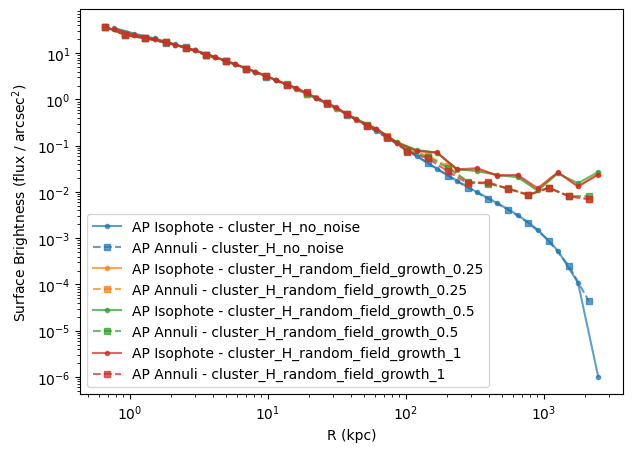

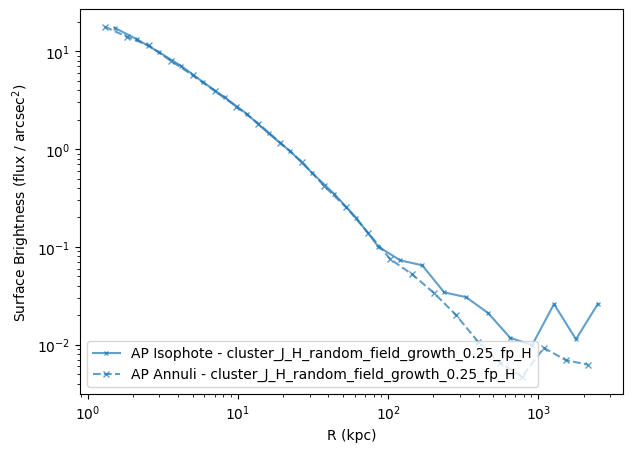

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

plot_sb_profiles(
    profiles=h_profiles,
    ax=ax,
    cosmology=cosmo,
    redshift=0.1,
    rad_output_unit="kpc",
    savefig=True,
    outdir=plotdir,
)

plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_sb_profiles(
    profiles=j_profiles,
    ax=ax,
    cosmology=cosmo,
    redshift=0.1,
    rad_output_unit="kpc",
    savefig=False,
    outdir=plotdir,
)
plt.show()

# plot_sb_profiles(profiles=h_profiles, ax=ax, specific_profile_prefix=['cluster_H_random_field_growth_0.25'])
# plot_sb_profiles(measurements=h_meas, specific_profile_prefix=['cluster_H_random_field_growth_0.25'], ax=ax, cosmology=cosmo, redshift=0.1, rad_output_unit='kpc')

# ax.set_xlim(300,2000)

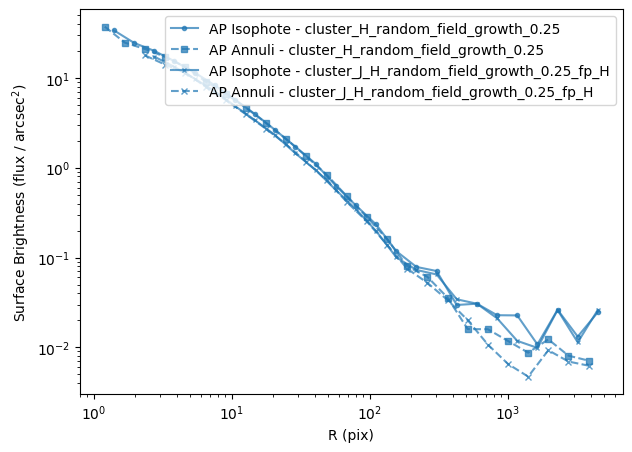

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))


plot_sb_profiles(
    profiles=h_profiles,
    ax=ax,
    specific_profile_prefix=["cluster_H_random_field_growth_0.25"],
    savefig=False,
    outdir=plotdir,
    legendloc="upper right",
)

plot_sb_profiles(
    profiles=j_profiles, ax=ax, savefig=False, outdir=plotdir, legendloc="upper right"
)


plt.show()

<Axes: xlabel='R (kpc)', ylabel='Surface Brightness (flux / arcsec$^2$)'>

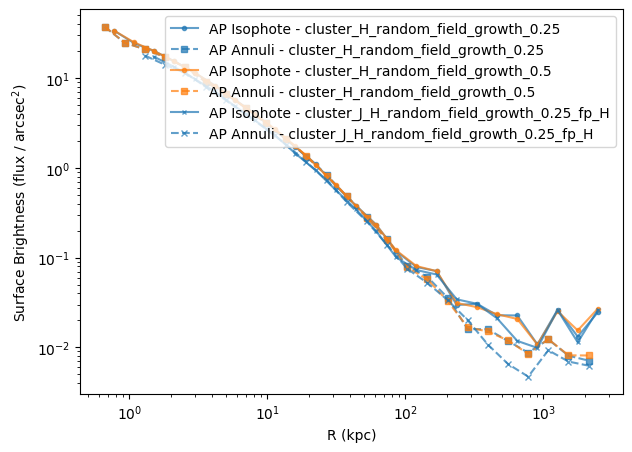

In [ ]:
prefix_colors = {
    "fluctuations": "tab:orange",
    "no_noise": "teal",
    "loaded_mask": "tab:green",
    "random_field": "hotpink",
    "random_field_growth_0.25": "red",
    "random_field_growth_0.5": "gold",
    "random_field_growth_1": "salmon",
    "random_field_growth_1.25": "purple",
}

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_sb_profiles(
    profiles=h_profiles,
    cosmology=cosmo,
    redshift=0.1,
    rad_output_unit="kpc",
    specific_profile_prefix=[
        "cluster_H_random_field_growth_0.25",
        "cluster_H_random_field_growth_0.5",
    ],
    prefix_colors=prefix_colors,
    savefig=True,
    outdir="plots",
    ax=ax,
)

plot_sb_profiles(
    profiles=j_profiles,
    cosmology=cosmo,
    redshift=0.1,
    rad_output_unit="kpc",
    specific_profile_prefix=[
        "cluster_J_H_random_field_growth_0.25_fp_H",
    ],
    prefix_colors=prefix_colors,
    savefig=True,
    outdir="plots",
    ax=ax,
    legendloc="upper right",
)

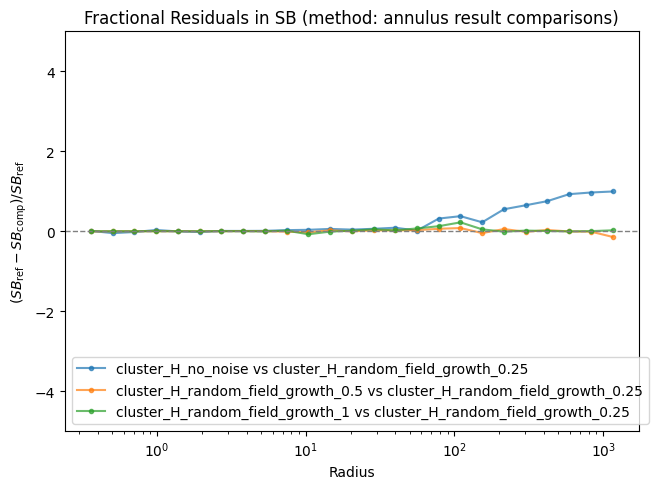

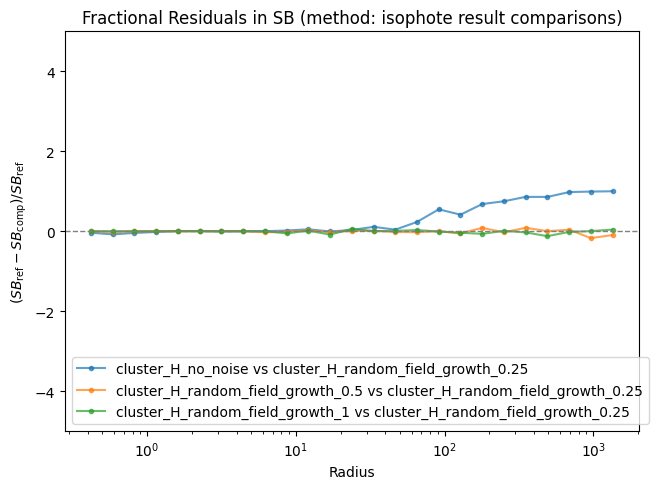

In [ ]:
plot_residual_comparison(
    reference_label="cluster_H_random_field_growth_0.25",
    profiles=h_profiles,
    method="annulus",
    ylims=[-5, 5],
    savefig=True,
    outdir=plotdir,
)
plt.show()


plot_residual_comparison(
    reference_label="cluster_H_random_field_growth_0.25",
    profiles=h_profiles,
    method="isophote",
    ylims=[-5, 5],
    savefig=True,
    outdir=plotdir,
)

plt.show()

# plot_residual_comparison(
#     reference_label="cluster_H_random_field_growth_0.25",
#     reference_from="measurements",
#     compare_from="measurements",
#     measurements= h_meas,
#     method="annulus",
#     ylims=[-10,10],
# )

# plt.show()

# Plotting shape profiles


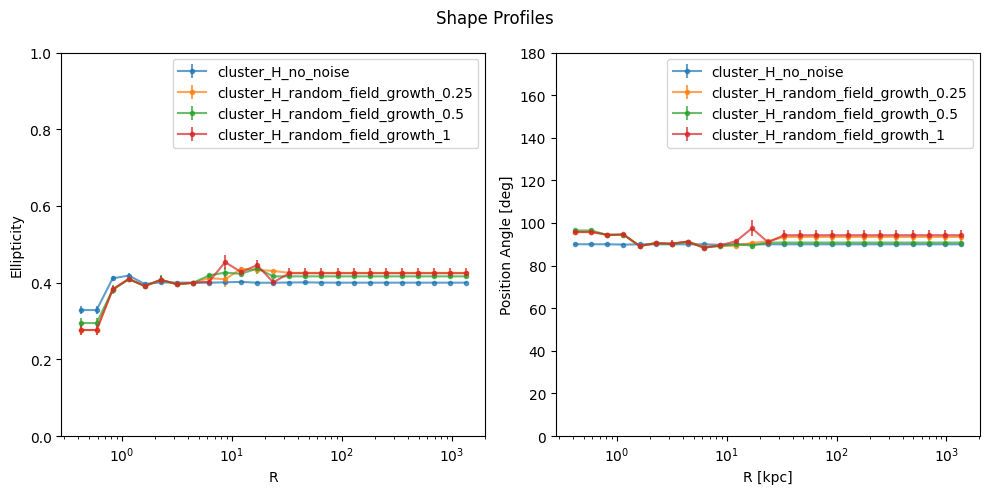

In [ ]:
profiles = h_profiles
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)


for label, prof in profiles:
    ax[0].errorbar(
        prof["R"],
        prof["ellip"],
        yerr=prof["ellip_e"],
        label=label,
        fmt="o-",
        ms=3,
        alpha=0.7,
    )
    ax[1].errorbar(
        prof["R"], prof["pa"], yerr=prof["pa_e"], label=label, fmt="o-", ms=3, alpha=0.7
    )

ax[0].set_xlabel("R")
ax[0].set_ylabel("Ellipticity")
ax[0].set_ylim(0, 1)
ax[0].legend()
ax[0].set_xscale("log")


ax[1].set_xlabel("R [kpc]")
ax[1].set_ylabel("Position Angle [deg]")
ax[1].set_ylim(0, 180)
ax[1].legend()
ax[1].set_xscale("log")

fig.suptitle("Shape Profiles")
plt.tight_layout()
plt.show()

# Fractional difference between a reference profile from Annuli method and the rest of the test profiles from the same method

In [ ]:
reference_label = "random_field_growth_0.25"

meas_dict = {label: meas for label, meas in measurements}

if reference_label not in meas_dict:
    raise ValueError(f"Reference label '{reference_label}' not found in measurements!")

ref_meas = meas_dict[reference_label]

ref_r_flux = dict(zip(ref_meas["R_kpc"], ref_meas["Clipped_median_flux_annulus"]))

fig, ax = plt.subplots(figsize=(7, 5))

for label, meas in measurements:
    if label == reference_label:
        continue

    other_r = meas["R_kpc"].values
    other_flux = meas["Clipped_median_flux_annulus"].values

    common_r = np.array([r for r in other_r if r in ref_r_flux])

    if len(common_r) == 0:
        print(f"No common radii found between '{reference_label}' and '{label}'")
        continue

    ref_flux_vals = np.array([ref_r_flux[r] for r in common_r])
    other_flux_vals = np.array(
        [
            meas.loc[meas["R_kpc"] == r, "Clipped_median_flux_annulus"].values[0]
            for r in common_r
        ]
    )

    residual_fraction = (ref_flux_vals - other_flux_vals) / ref_flux_vals

    color = prefix_colors.get(label, "black")
    ax.plot(
        common_r,
        residual_fraction,
        label=f"{label} vs {reference_label}",
        color=color,
        linestyle="-",
        marker="o",
        ms=3,
        alpha=0.7,
    )

ax.axhline(0, color="gray", linestyle="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("R [kpc]")
ax.set_ylabel(
    rf"(SB$\rm _{{{reference_label}}}$ - SB$\rm _{{profile}}$) / SB$\rm _{{{reference_label}}}$"
)

ax.set_title(f"Fractional Residuals in SB measured in Annuli Method")
ax.legend()

# ax.set_xlim(0,300)
ax.set_ylim(-0.1, 0.1)
plt.tight_layout()
plt.show()

# Fractional change in SB between a given profile from isophote method and the rest 

In [ ]:
reference_label = "no_noise"

prof_dict = {label: prof for label, prof in profiles}
if reference_label not in prof_dict:
    raise ValueError(f"Reference label '{reference_label}' not found in profiles!")

ref_prof = prof_dict[reference_label]
ref_r = ref_prof["R_kpc"].values
ref_flux = ref_prof["I"].values

fig, ax = plt.subplots(figsize=(7, 5))

#  Comparing other isophote profile measurements
for label, prof in profiles:
    if label == reference_label:
        continue

    other_r = prof["R_kpc"].values
    other_flux = prof["I"].values

    interp_flux = np.interp(ref_r, other_r, other_flux)
    residual_fraction = (ref_flux - interp_flux) / ref_flux

    color = prefix_colors.get(label, "black")
    ax.plot(
        ref_r,
        residual_fraction,
        label=f"Isophote - {label}",
        color=color,
        linestyle="-",
        marker="o",
        ms=3,
        alpha=0.7,
    )

#  Comparing annuli profile measurements
for label, meas in measurements:
    other_r = meas["R_kpc"].values
    other_flux = meas["Clipped_median_flux_annulus"].values

    interp_flux = np.interp(ref_r, other_r, other_flux)
    residual_fraction = (ref_flux - interp_flux) / ref_flux

    color = prefix_colors.get(label, "black")
    ax.plot(
        ref_r,
        residual_fraction,
        label=f"Annuli - {label}",
        color=color,
        linestyle="--",
        marker="s",
        ms=3,
        alpha=0.7,
    )

ax.plot(
    ref_r,
    np.zeros_like(ref_r),
    label=f"{reference_label} (isophote)",
    color=prefix_colors.get(reference_label, "gray"),
    linestyle="dotted",
    linewidth=2,
)


ax.axhline(0, color="gray", linestyle="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("R [kpc]")

ax.set_ylabel(
    rf"(SB$\rm _{{{reference_label}}}$ - SB$\rm _{{profile}}$) / SB$\rm _{{{reference_label}}}$"
)
ax.set_title(f"Fractional Residuals in SB measured in Annuli and Isophote Methods")
ax.set_ylim(-10, 3)

ax.legend()
plt.tight_layout()
plt.show()